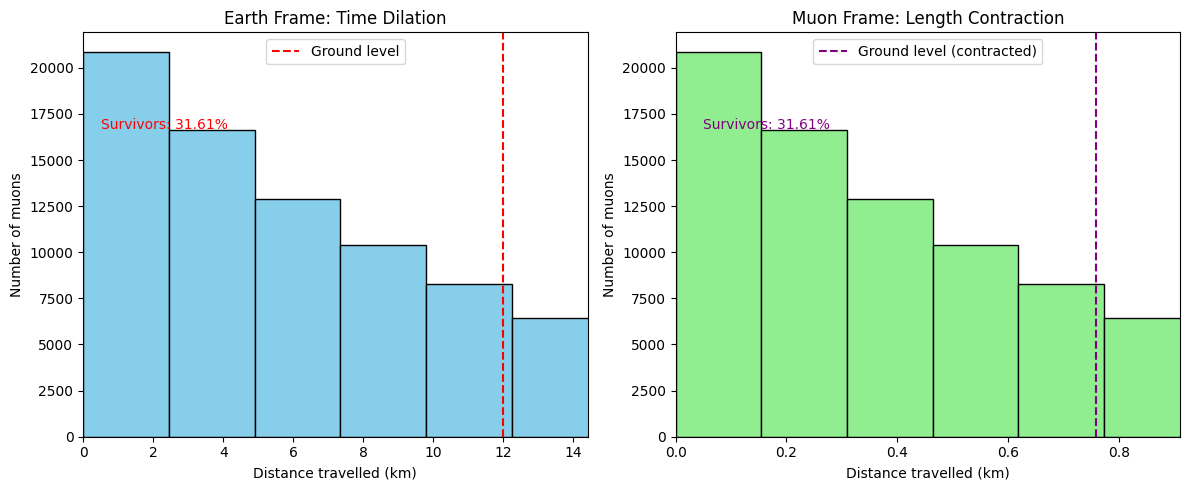

Relativistic gamma: 15.82
Dilated lifetime (Earth frame): 34.80 μs
Contracted atmosphere thickness (Muon frame): 758.57 m
Survivors (Earth frame): 31.61%
Survivors (Muon frame): 31.61%


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
c = 3e8  # m/s
tau0 = 2.2e-6  # proper lifetime (s)
v = 0.998 * c
gamma = 1 / np.sqrt(1 - (v/c)**2)
tau_earth = gamma * tau0

# Atmosphere thickness
L_earth = 12000  # m
L_muon = L_earth / gamma

# Simulation
N = 100000
decay_times_muon = np.random.exponential(tau0, N)
decay_distances_earth = v * gamma * decay_times_muon
decay_distances_muon = v * decay_times_muon

# Survivors
survivors_earth = np.sum(decay_distances_earth >= L_earth) / N
survivors_muon = np.sum(decay_distances_muon >= L_muon) / N

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Earth frame
axs[0].hist(decay_distances_earth/1000, bins=50, color='skyblue', edgecolor='black')
axs[0].axvline(L_earth/1000, color='red', linestyle='--', label='Ground level')
axs[0].set_xlim(0, L_earth/1000*1.2)
axs[0].set_xlabel('Distance travelled (km)')
axs[0].set_ylabel('Number of muons')
axs[0].set_title('Earth Frame: Time Dilation')
axs[0].legend()
axs[0].text(0.5, max(np.histogram(decay_distances_earth/1000, bins=50)[0])*0.8,
            f'Survivors: {survivors_earth*100:.2f}%', color='red')

# Muon frame
axs[1].hist(decay_distances_muon/1000, bins=50, color='lightgreen', edgecolor='black')
axs[1].axvline(L_muon/1000, color='purple', linestyle='--', label='Ground level (contracted)')
axs[1].set_xlim(0, L_muon/1000*1.2)
axs[1].set_xlabel('Distance travelled (km)')
axs[1].set_ylabel('Number of muons')
axs[1].set_title('Muon Frame: Length Contraction')
axs[1].legend()
axs[1].text(0.05, max(np.histogram(decay_distances_muon/1000, bins=50)[0])*0.8,
            f'Survivors: {survivors_muon*100:.2f}%', color='purple')

plt.tight_layout()
plt.show()

# Summary
print(f"Relativistic gamma: {gamma:.2f}")
print(f"Dilated lifetime (Earth frame): {tau_earth*1e6:.2f} μs")
print(f"Contracted atmosphere thickness (Muon frame): {L_muon:.2f} m")
print(f"Survivors (Earth frame): {survivors_earth*100:.2f}%")
print(f"Survivors (Muon frame): {survivors_muon*100:.2f}%")
